# Getting Started with Urbanity

This notebook introduces the core concepts of **Urbanity**: creating a `Map` object, defining a study area boundary, and exploring the interactive basemap.

Urbanity is designed around an **object-oriented workflow** that mirrors the urban planning process:

1. Instantiate a `Map` — your base canvas.
2. Define a study area (bounding box drawn interactively, or a provided GeoJSON/shapefile).
3. Fetch urban data layers (streets, buildings, population, POIs, street view imagery).
4. Construct the heterogeneous **UrbanGraph** and run analyses.

In [1]:
from urbanity import Map
import geopandas as gpd

## 2  Creating a Map Object

The `Map` class inherits from `ipyleaflet.Map` and pre-loads several background layers (CartoDB, Google Streets, Google Hybrid, Google Terrain). Passing a country name centres the view automatically.

In [2]:
# Centre the map on Singapore
m = Map(country='Singapore')
m

Map(center=[1.357107, 103.8194992], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

> **Tip:** Use the polygon or rectangle draw tool in the map controls to sketch your study area, then run `m.add_bbox()` to capture it. Alternatively, load a pre-existing GeoJSON boundary as shown below.

## 3  Defining a Study Area via GeoJSON

If you already have a boundary file, pass its path to `add_polygon_boundary`. This approach is fully reproducible and does not require interactive drawing.

In [3]:
# Load the bundled Tanjong Pagar (Singapore) sample boundary
m.add_polygon_boundary('data/tanjong_pagar_singapore.geojson', layer_name='Tanjong Pagar')

# Confirm the boundary is assigned
print("Polygon bounds set:", m.polygon_bounds is not None)
print("CRS:", m.polygon_bounds.crs)
m.polygon_bounds.head()

Polygon bounds set: True
CRS: epsg:4326


,name,website,admin_level,boundary,id,timestamp,version,tags,osm_type,addr:postcode,border_type,changeset,geom_type,geometry
0,Tanjong Pagar GRC,None,None,political,952361601003,0,-1,"{""political_division"":""parl_const"",""type"":""mul...",relation,None,None,0.0,Polygon,"POLYGON ((103.8458 1.26163, 103.8464 1.26228, ..."


## 4  Exploring the Boundary

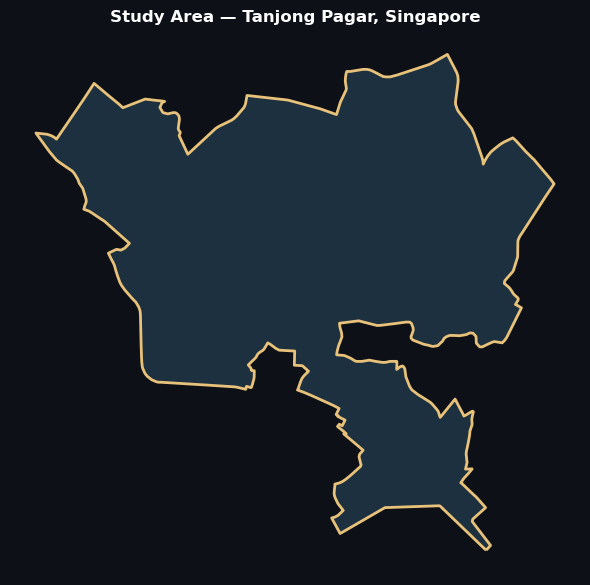

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6), facecolor='#0d1117')
ax.set_facecolor('#0d1117')
m.polygon_bounds.boundary.plot(ax=ax, color='#e8c27a', linewidth=2)
m.polygon_bounds.plot(ax=ax, color='#457b9d', alpha=0.3)
ax.set_axis_off()
ax.set_title('Study Area — Tanjong Pagar, Singapore',
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5  Automated OSM Data Download

Urbanity's new data access workflow **automatically locates and downloads the smallest available OSM extract** (from Geofabrik or BBBike) that fully contains your study area — no more hunting for `.osm.pbf` links manually.

The extract is cached locally in `./data/` so subsequent calls are instant.

```python
# This is handled internally by methods such as get_street_network:
G, nodes, edges = m.get_street_network()
```

See **Tutorial 02 – Street Network** for a full walkthrough.

## 6  Environment Variables (Optional)

Some features (street view imagery, satellite tiles) require API keys stored in a `.env` file in your project root:

```
MAPILLARY_API_TOKEN=<your-token>
MAPBOX_API_TOKEN=<your-token>
```

Core functions such as `get_street_network` and `get_urban_graph` work without any API keys.

## Summary

| Step | Method | Notes |
|---|---|---|
| Create map | `Map(country=...)` | Centres on country centroid |
| Draw study area | draw tool → `m.add_bbox()` | Interactive |
| Load GeoJSON boundary | `m.add_polygon_boundary(path)` | Reproducible |
| Auto-download OSM data | handled internally | Geofabrik / BBBike |

Continue to **Tutorial 02** to build your first street network.